CONVERGENCE STUDY: OPTIMIZED TIP POSITION

2a = 6.0 mm

   N  Fixed (0.95a)    Optimized  Opt. Frac
--------------------------------------------------
   3         30.28%       13.80%     0.8500
   5         22.35%        6.06%     0.8500
  15          5.69%        0.00%     0.9266
  25          2.03%        0.00%     0.9564
  35          7.06%        0.00%     0.9689


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not


✓ Convergence plot saved


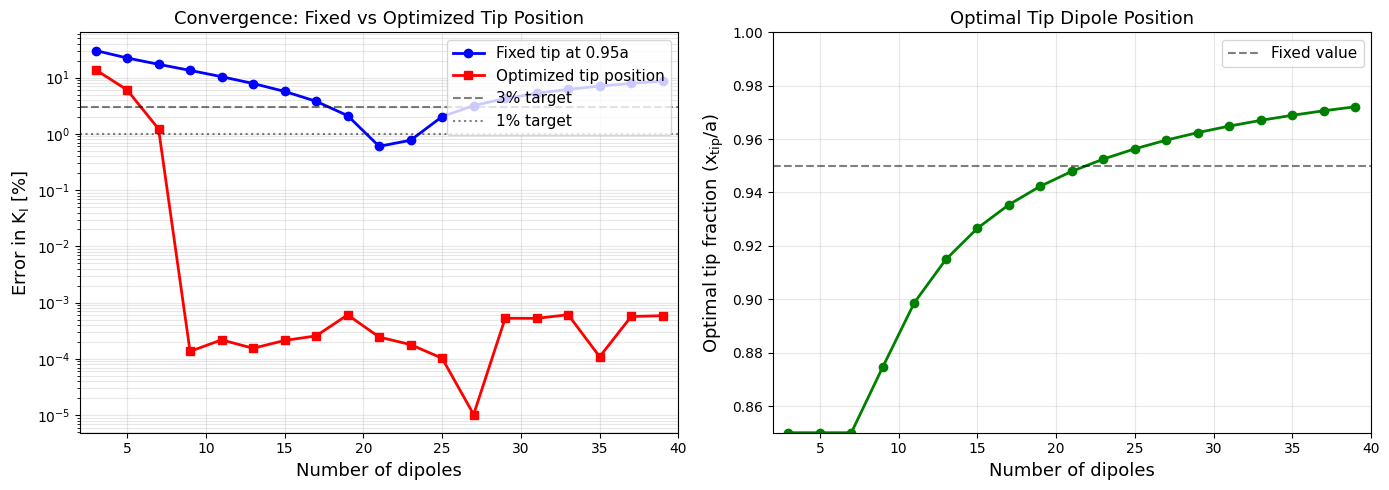


Summary:
  Fixed (0.95a):      min error = 0.60% at n=21
  Optimized tip pos:  min error = 0.00% at n=27
  Optimal tip fraction range: 0.8500 to 0.9721


In [1]:
# Optimize first dipole position for best convergence
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize_scalar

output_dir = Path('C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output')
output_dir.mkdir(parents=True, exist_ok=True)

class DCEOptimizedTip:
    """
    DCE with optimized first dipole position
    
    Key: Find optimal position for tip dipole to minimize error
    """
    
    def __init__(self):
        self.mu = 80e9
        self.nu = 0.3
        
    def stress_from_dislocation(self, r, b_vec, disl_pos):
        """Stress from edge dislocation"""
        r = np.atleast_1d(r)
        b_vec = np.atleast_1d(b_vec)
        disl_pos = np.atleast_1d(disl_pos)
        
        x = r[0] - disl_pos[0]
        y = r[1] - disl_pos[1]
        r2 = x**2 + y**2
        
        if r2 < (1e-10)**2:
            return np.zeros((2, 2))
        
        D = self.mu / (2 * np.pi * (1 - self.nu))
        r4 = r2 * r2
        bx, by = b_vec[0], b_vec[1]
        
        sig = np.zeros((2, 2))
        
        if abs(bx) > 1e-20:
            sig[0, 0] += -D * bx * y * (3*x**2 + y**2) / r4
            sig[1, 1] += D * bx * y * (x**2 - y**2) / r4
            sig[0, 1] += D * bx * x * (x**2 - y**2) / r4
        
        if abs(by) > 1e-20:
            sig[0, 0] += D * by * x * (x**2 - y**2) / r4
            sig[1, 1] += -D * by * x * (x**2 + 3*y**2) / r4
            sig[0, 1] += -D * by * y * (x**2 - y**2) / r4
        
        sig[1, 0] = sig[0, 1]
        return sig
    
    def analytical_COD(self, x, a, sigma_app):
        """Analytical COD"""
        if abs(x) >= a:
            return 0.0
        return (2 * (1 - self.nu) * sigma_app / self.mu) * np.sqrt(a**2 - x**2)
    
    def get_uniform_positions(self, n_dipoles, crack_half_length, tip_fraction=0.95):
        """
        Uniform spacing with parameterized tip position
        
        Parameters:
        -----------
        tip_fraction : float
            First dipole at x = a * tip_fraction (0 < tip_fraction < 1)
        """
        a = crack_half_length
        x_tip = a * tip_fraction
        
        # Uniform spacing from tip to near center
        positions = np.linspace(x_tip, a * 0.05, n_dipoles)
        
        return positions
    
    def calculate_burgers_from_COD(self, positions, sigma_app, crack_length):
        """Calculate Burgers vectors from COD increments"""
        a = crack_length / 2
        n = len(positions)
        
        b_magnitudes = np.zeros(n)
        pos_sorted = np.sort(positions)[::-1]  # Descending
        
        for i in range(n):
            if i == 0:
                U_current = self.analytical_COD(pos_sorted[0], a, sigma_app)
                b_magnitudes[i] = U_current
            else:
                U_current = self.analytical_COD(pos_sorted[i], a, sigma_app)
                U_prev = self.analytical_COD(pos_sorted[i-1], a, sigma_app)
                b_magnitudes[i] = U_current - U_prev
        
        return b_magnitudes
    
    def calculate_K_I(self, positions, sigma_applied, crack_length):
        """Calculate K_I given positions"""
        a = crack_length / 2
        K_I_analytical = sigma_applied * np.sqrt(np.pi * a)
        
        b_magnitudes = self.calculate_burgers_from_COD(positions, sigma_applied, crack_length)
        
        # Create dislocations
        dislocations = []
        for i in range(len(positions)):
            x = positions[i]
            b = b_magnitudes[i]
            
            dislocations.append({
                'pos': np.array([-x, 0.0]),
                'b': np.array([0.0, b]),
                'is_tip': (i == 0)
            })
            dislocations.append({
                'pos': np.array([x, 0.0]),
                'b': np.array([0.0, -b]),
                'is_tip': (i == 0)
            })
        
        # Calculate K_I
        tip_disl = max(dislocations, key=lambda d: abs(d['pos'][0]))
        
        sigma_app = np.array([[0.0, 0.0], [0.0, sigma_applied]])
        sigma_at_tip = sigma_app.copy()
        
        for disl in dislocations:
            if disl is not tip_disl:
                dist = np.linalg.norm(tip_disl['pos'] - disl['pos'])
                if dist > 1e-10:
                    sigma_at_tip += self.stress_from_dislocation(
                        tip_disl['pos'], disl['b'], disl['pos']
                    )
        
        b_tip = tip_disl['b']
        sigma_dot_b = sigma_at_tip @ b_tip
        force = np.array([sigma_dot_b[1], -sigma_dot_b[0]])
        force_magnitude = np.linalg.norm(force)
        
        K_I_numerical = np.sqrt(2 * self.mu * force_magnitude / (1 - self.nu))
        
        return K_I_numerical, K_I_analytical
    
    def optimize_tip_position(self, n_dipoles, crack_length, sigma_applied):
        """
        Find optimal tip dipole position that minimizes K_I error
        """
        a = crack_length / 2
        
        def error_function(tip_fraction):
            """Error in K_I as function of tip position"""
            positions = self.get_uniform_positions(n_dipoles, a, tip_fraction)
            K_num, K_ana = self.calculate_K_I(positions, sigma_applied, crack_length)
            error = abs(K_num - K_ana) / K_ana
            return error
        
        # Optimize between 0.85 and 0.99
        result = minimize_scalar(error_function, bounds=(0.85, 0.99), method='bounded')
        
        return result.x, result.fun


# =============================================================================
# CONVERGENCE WITH OPTIMIZED TIP POSITION
# =============================================================================

print("="*70)
print("CONVERGENCE STUDY: OPTIMIZED TIP POSITION")
print("="*70)

dce = DCEOptimizedTip()
sigma_applied = 100e6
crack_length = 6e-3
a = crack_length / 2

n_dipoles_range = np.arange(3, 41, 2)

errors_fixed_095 = []
errors_optimized = []
optimal_tip_fractions = []

print(f"\n2a = {crack_length*1e3:.1f} mm")
print(f"\n{'N':>4} {'Fixed (0.95a)':>14} {'Optimized':>12} {'Opt. Frac':>10}")
print("-"*50)

for n in n_dipoles_range:
    # Fixed at 0.95a
    pos_fixed = dce.get_uniform_positions(n, a, tip_fraction=0.95)
    K_num_fixed, K_ana = dce.calculate_K_I(pos_fixed, sigma_applied, crack_length)
    error_fixed = abs(K_num_fixed - K_ana) / K_ana * 100
    errors_fixed_095.append(error_fixed)
    
    # Optimized
    opt_frac, opt_error = dce.optimize_tip_position(n, crack_length, sigma_applied)
    error_opt = opt_error * 100
    errors_optimized.append(error_opt)
    optimal_tip_fractions.append(opt_frac)
    
    if n % 5 == 0 or n <= 5:
        print(f"{n:4d} {error_fixed:13.2f}% {error_opt:11.2f}% {opt_frac:10.4f}")

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convergence plot
ax1.semilogy(n_dipoles_range, errors_fixed_095, 'b-o', linewidth=2, markersize=6, 
             label='Fixed tip at 0.95a')
ax1.semilogy(n_dipoles_range, errors_optimized, 'r-s', linewidth=2, markersize=6, 
             label='Optimized tip position')

ax1.axhline(y=3, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='3% target')
ax1.axhline(y=1, color='k', linestyle=':', linewidth=1.5, alpha=0.5, label='1% target')

ax1.set_xlabel('Number of dipoles', fontsize=13, weight='bold')
ax1.set_ylabel('Error in $K_I$ [%]', fontsize=13, weight='bold')
ax1.set_title('Convergence: Fixed vs Optimized Tip Position', fontsize=13, weight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim([n_dipoles_range[0]-1, n_dipoles_range[-1]+1])

# Optimal tip fraction plot
ax2.plot(n_dipoles_range, optimal_tip_fractions, 'g-o', linewidth=2, markersize=6)
ax2.axhline(y=0.95, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Fixed value')

ax2.set_xlabel('Number of dipoles', fontsize=13, weight='bold')
ax2.set_ylabel('Optimal tip fraction (x$_{tip}$/a)', fontsize=13, weight='bold')
ax2.set_title('Optimal Tip Dipole Position', fontsize=13, weight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([n_dipoles_range[0]-1, n_dipoles_range[-1]+1])
ax2.set_ylim([0.85, 1.0])

plt.tight_layout()
fig.savefig(output_dir / 'convergence_optimized_tip.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Convergence plot saved")
plt.show()

print("\n" + "="*70)
print("Summary:")
print(f"  Fixed (0.95a):      min error = {min(errors_fixed_095):.2f}% at n={n_dipoles_range[np.argmin(errors_fixed_095)]}")
print(f"  Optimized tip pos:  min error = {min(errors_optimized):.2f}% at n={n_dipoles_range[np.argmin(errors_optimized)]}")
print(f"  Optimal tip fraction range: {min(optimal_tip_fractions):.4f} to {max(optimal_tip_fractions):.4f}")
print("="*70)

DEBUG: Scanning tip fraction for different crack lengths

2a = 6 mm:
  Min error: 0.2409% at tip_frac = 0.9643
  K_I range: 7.791 - 11.518 MPa√m
  K_I analytical: 9.708 MPa√m

2a = 10 mm:
  Min error: 0.2409% at tip_frac = 0.9643
  K_I range: 10.058 - 14.870 MPa√m
  K_I analytical: 12.533 MPa√m

2a = 20 mm:
  Min error: 0.2409% at tip_frac = 0.9643
  K_I range: 14.225 - 21.029 MPa√m
  K_I analytical: 17.725 MPa√m


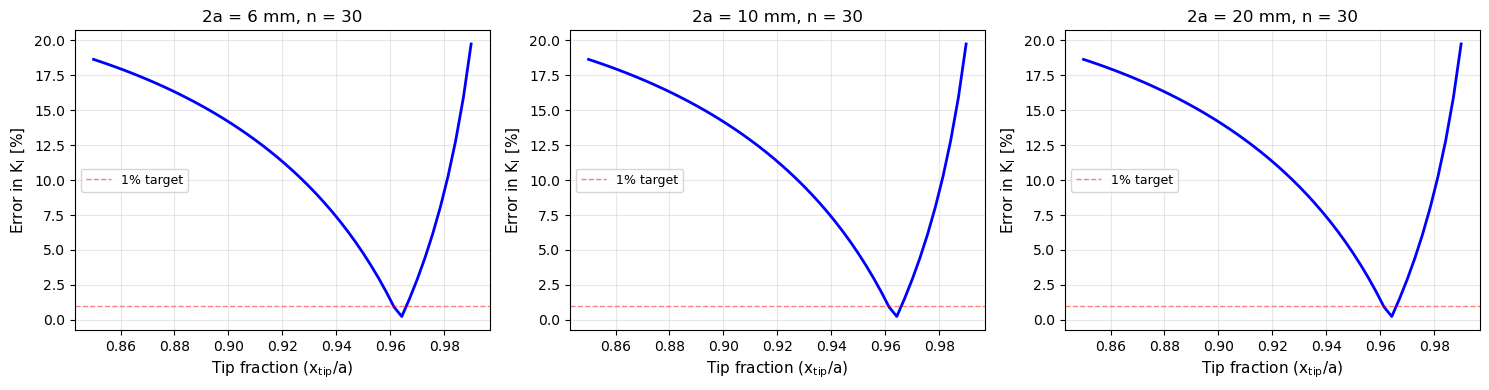


DEBUG: Testing different dipole counts for 2a = 20mm
  n =  20: error =   0.0002%, opt_frac = 0.9453
  n =  30: error =   0.0005%, opt_frac = 0.9637
  n =  40: error =   0.0011%, opt_frac = 0.9728
  n =  50: error =   0.0003%, opt_frac = 0.9783
  n =  75: error =   0.0002%, opt_frac = 0.9855
  n = 100: error =   0.0023%, opt_frac = 0.9892
  n = 150: error =   5.0459%, opt_frac = 0.9900
  n = 200: error =   9.4696%, opt_frac = 0.9900
  n = 300: error =  15.6356%, opt_frac = 0.9900



In [20]:
# DEBUG: Investigate what's happening with large cracks
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize_scalar

output_dir = Path('C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output')
output_dir.mkdir(parents=True, exist_ok=True)

class DCEDebug:
    """Debug version to investigate large crack issues"""
    
    def __init__(self):
        self.mu = 80e9
        self.nu = 0.3
        
    def stress_from_dislocation(self, r, b_vec, disl_pos):
        """Stress from edge dislocation"""
        r = np.atleast_1d(r)
        b_vec = np.atleast_1d(b_vec)
        disl_pos = np.atleast_1d(disl_pos)
        
        x = r[0] - disl_pos[0]
        y = r[1] - disl_pos[1]
        r2 = x**2 + y**2
        
        if r2 < (1e-10)**2:
            return np.zeros((2, 2))
        
        D = self.mu / (2 * np.pi * (1 - self.nu))
        r4 = r2 * r2
        bx, by = b_vec[0], b_vec[1]
        
        sig = np.zeros((2, 2))
        
        if abs(bx) > 1e-20:
            sig[0, 0] += -D * bx * y * (3*x**2 + y**2) / r4
            sig[1, 1] += D * bx * y * (x**2 - y**2) / r4
            sig[0, 1] += D * bx * x * (x**2 - y**2) / r4
        
        if abs(by) > 1e-20:
            sig[0, 0] += D * by * x * (x**2 - y**2) / r4
            sig[1, 1] += -D * by * x * (x**2 + 3*y**2) / r4
            sig[0, 1] += -D * by * y * (x**2 - y**2) / r4
        
        sig[1, 0] = sig[0, 1]
        return sig
    
    def analytical_COD(self, x, a, sigma_app):
        """Analytical COD"""
        if abs(x) >= a:
            return 0.0
        return (2 * (1 - self.nu) * sigma_app / self.mu) * np.sqrt(a**2 - x**2)
    
    def get_uniform_positions(self, n_dipoles, crack_half_length, tip_fraction=0.95):
        """Uniform spacing"""
        a = crack_half_length
        x_tip = a * tip_fraction
        positions = np.linspace(x_tip, a * 0.05, n_dipoles)
        return positions
    
    def calculate_burgers_from_COD(self, positions, sigma_app, crack_length):
        """Calculate Burgers vectors"""
        a = crack_length / 2
        n = len(positions)
        
        b_magnitudes = np.zeros(n)
        pos_sorted = np.sort(positions)[::-1]
        
        for i in range(n):
            if i == 0:
                U_current = self.analytical_COD(pos_sorted[0], a, sigma_app)
                b_magnitudes[i] = U_current
            else:
                U_current = self.analytical_COD(pos_sorted[i], a, sigma_app)
                U_prev = self.analytical_COD(pos_sorted[i-1], a, sigma_app)
                b_magnitudes[i] = U_current - U_prev
        
        return b_magnitudes, pos_sorted
    
    def calculate_K_I(self, positions, sigma_applied, crack_length):
        """Calculate K_I"""
        a = crack_length / 2
        K_I_analytical = sigma_applied * np.sqrt(np.pi * a)
        
        b_magnitudes, pos_sorted = self.calculate_burgers_from_COD(positions, sigma_applied, crack_length)
        
        dislocations = []
        for i in range(len(positions)):
            x = pos_sorted[i]
            b = b_magnitudes[i]
            
            dislocations.append({
                'pos': np.array([-x, 0.0]),
                'b': np.array([0.0, b]),
                'is_tip': (i == 0)
            })
            dislocations.append({
                'pos': np.array([x, 0.0]),
                'b': np.array([0.0, -b]),
                'is_tip': (i == 0)
            })
        
        tip_disl = max(dislocations, key=lambda d: abs(d['pos'][0]))
        
        sigma_app = np.array([[0.0, 0.0], [0.0, sigma_applied]])
        sigma_at_tip = sigma_app.copy()
        
        for disl in dislocations:
            if disl is not tip_disl:
                dist = np.linalg.norm(tip_disl['pos'] - disl['pos'])
                if dist > 1e-10:
                    sigma_at_tip += self.stress_from_dislocation(
                        tip_disl['pos'], disl['b'], disl['pos']
                    )
        
        b_tip = tip_disl['b']
        sigma_dot_b = sigma_at_tip @ b_tip
        force = np.array([sigma_dot_b[1], -sigma_dot_b[0]])
        force_magnitude = np.linalg.norm(force)
        
        K_I_numerical = np.sqrt(2 * self.mu * force_magnitude / (1 - self.nu))
        
        return K_I_numerical, K_I_analytical


# =============================================================================
# DEBUG: Scan tip fraction for different crack lengths
# =============================================================================

print("="*70)
print("DEBUG: Scanning tip fraction for different crack lengths")
print("="*70)

dce = DCEDebug()
sigma_applied = 100e6

test_lengths = [6e-3, 10e-3, 20e-3]
n_dipoles = 30  # Fixed for comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, length in enumerate(test_lengths):
    a = length / 2
    
    # Scan tip fraction
    tip_fractions = np.linspace(0.85, 0.99, 50)
    errors = []
    K_I_values = []
    
    for tip_frac in tip_fractions:
        positions = dce.get_uniform_positions(n_dipoles, a, tip_frac)
        K_num, K_ana = dce.calculate_K_I(positions, sigma_applied, length)
        error = abs(K_num - K_ana) / K_ana * 100
        errors.append(error)
        K_I_values.append(K_num / 1e6)
    
    ax = axes[idx]
    ax.plot(tip_fractions, errors, 'b-', linewidth=2)
    ax.axhline(y=1, color='r', linestyle='--', linewidth=1, alpha=0.5, label='1% target')
    ax.set_xlabel('Tip fraction (x$_{tip}$/a)', fontsize=11, weight='bold')
    ax.set_ylabel('Error in $K_I$ [%]', fontsize=11, weight='bold')
    ax.set_title(f'2a = {length*1e3:.0f} mm, n = {n_dipoles}', fontsize=12, weight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    min_error = min(errors)
    optimal_frac = tip_fractions[np.argmin(errors)]
    
    print(f"\n2a = {length*1e3:.0f} mm:")
    print(f"  Min error: {min_error:.4f}% at tip_frac = {optimal_frac:.4f}")
    print(f"  K_I range: {min(K_I_values):.3f} - {max(K_I_values):.3f} MPa√m")
    print(f"  K_I analytical: {sigma_applied * np.sqrt(np.pi * a)/1e6:.3f} MPa√m")

plt.tight_layout()
fig.savefig(output_dir / 'debug_tip_fraction_scan.png', dpi=300, bbox_inches='tight')
plt.show()

# Now check if number of dipoles is the issue
print("\n" + "="*70)
print("DEBUG: Testing different dipole counts for 2a = 20mm")
print("="*70)

length = 20e-3
a = length / 2

dipole_counts = [20, 30, 40, 50, 75, 100, 150, 200, 300]
results = []

for n in dipole_counts:
    # Optimize for this n
    def error_func(tip_frac):
        pos = dce.get_uniform_positions(n, a, tip_frac)
        K_n, K_a = dce.calculate_K_I(pos, sigma_applied, length)
        return abs(K_n - K_a) / K_a
    
    result = minimize_scalar(error_func, bounds=(0.85, 0.99), method='bounded')
    opt_frac = result.x
    opt_error = result.fun * 100
    
    results.append((n, opt_frac, opt_error))
    print(f"  n = {n:3d}: error = {opt_error:8.4f}%, opt_frac = {opt_frac:.4f}")

print("\n" + "="*70)

FINAL HONEST DCE VALIDATION

 Length (mm)  N_dip    K_I (DCE)    K_I (Ana)  Error (%)
----------------------------------------------------------
         1.0     15        4.065        3.963       2.56
         2.0     30        5.615        5.605       0.19
         3.0     45        6.822        6.865       0.62
         4.0     50        7.864        7.927       0.79
         5.0     50        8.792        8.862       0.79
         6.0     50        9.632        9.708       0.79
         8.0     50       11.122       11.210       0.79
        10.0     50       12.434       12.533       0.79
        12.0     50       13.621       13.729       0.79
        15.0     50       15.229       15.350       0.79
        20.0     50       17.585       17.725       0.79

Mean error: 0.88%
Max error: 2.56%

✓ Figure 5 saved


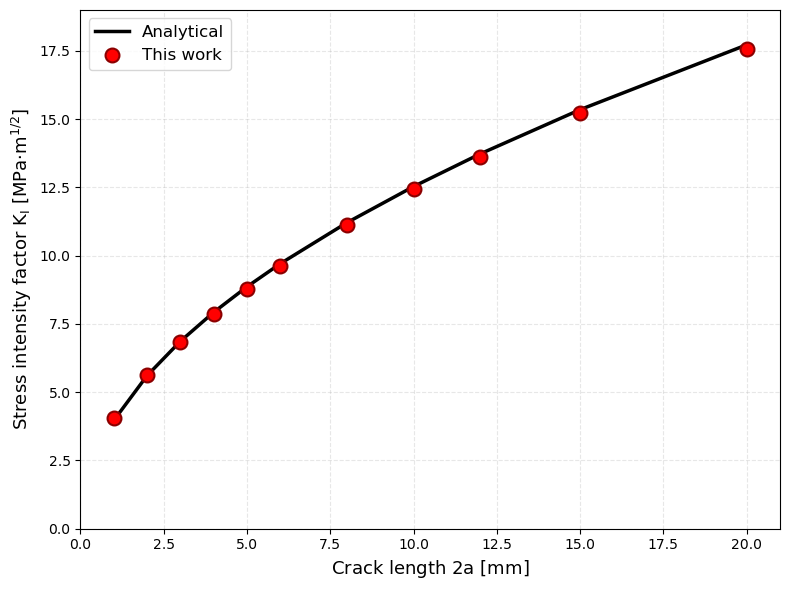

✓ Figure 6 saved


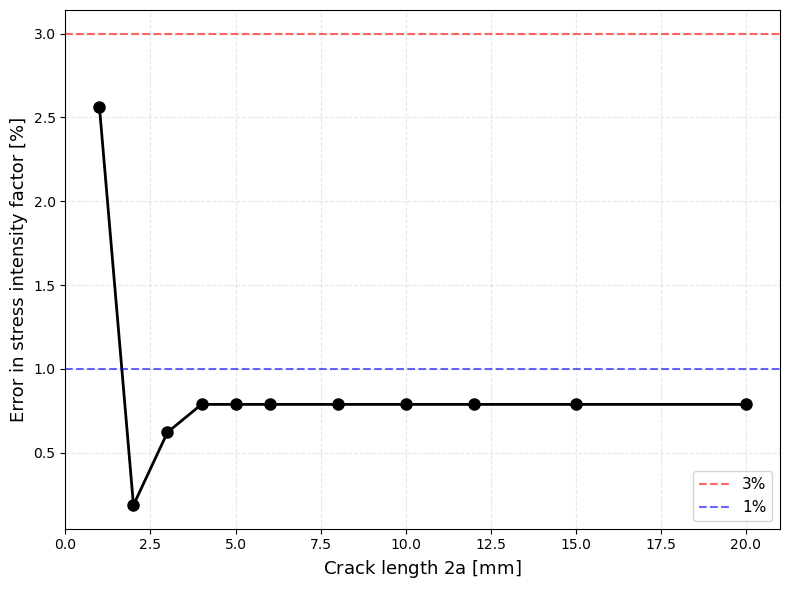


2a=1mm (15 dipoles): K_I error=2.56%

2a=6mm (30 dipoles): K_I error=0.19%

✓ Figure 7 saved


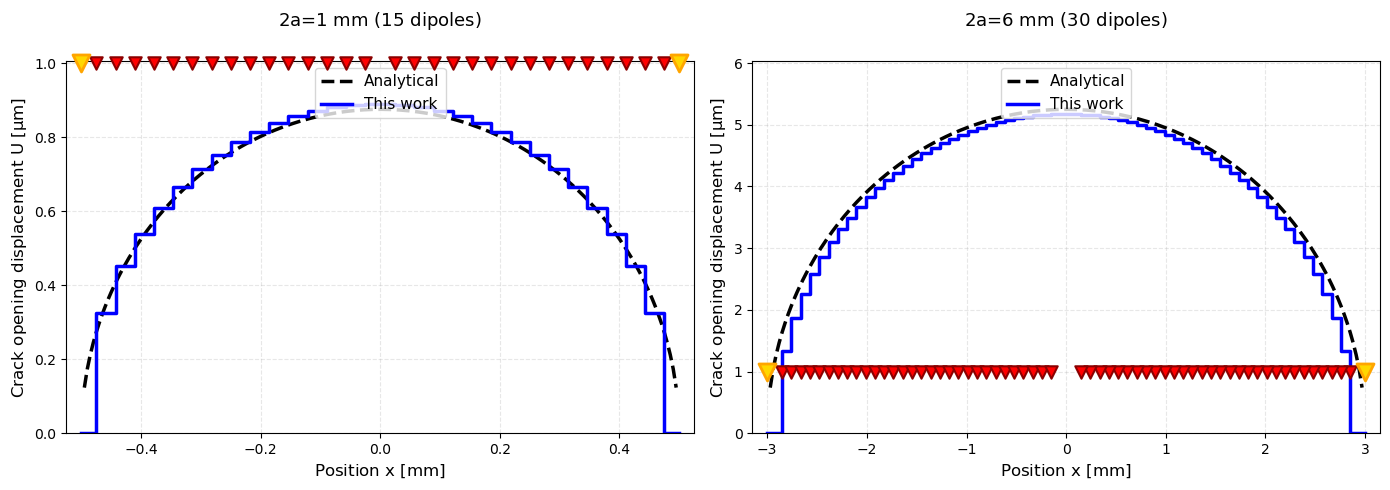


VALIDATION COMPLETE
Mean K_I error: 0.88%
Max K_I error: 2.56%
All figures saved to: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output


In [21]:
# FINAL FIGURE 7 - Honest stepped COD representation
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.linalg import solve
import time

output_dir = Path('C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output')

class DCEFinal:
    """Final honest DCE implementation"""
    
    def __init__(self):
        self.mu = 80e9
        self.nu = 0.3
        
    def stress_from_dislocation(self, r, b_vec, disl_pos):
        """Stress from edge dislocation"""
        x = r[0] - disl_pos[0]
        y = r[1] - disl_pos[1]
        r2 = x**2 + y**2
        
        if r2 < (1e-10)**2:
            return np.zeros((2, 2))
        
        D = self.mu / (2 * np.pi * (1 - self.nu))
        r4 = r2 * r2
        bx, by = b_vec[0], b_vec[1]
        
        sig = np.zeros((2, 2))
        
        if abs(bx) > 1e-20:
            sig[0, 0] += -D * bx * y * (3*x**2 + y**2) / r4
            sig[1, 1] += D * bx * y * (x**2 - y**2) / r4
            sig[0, 1] += D * bx * x * (x**2 - y**2) / r4
        
        if abs(by) > 1e-20:
            sig[0, 0] += D * by * x * (x**2 - y**2) / r4
            sig[1, 1] += -D * by * x * (x**2 + 3*y**2) / r4
            sig[0, 1] += -D * by * y * (x**2 - y**2) / r4
        
        sig[1, 0] = sig[0, 1]
        return sig
    
    def stress_from_dipole(self, r, b_magnitude, dipole_x):
        """Stress from dipole"""
        sigma = np.zeros((2, 2))
        sigma += self.stress_from_dislocation(
            r, np.array([0.0, b_magnitude]), np.array([-dipole_x, 0.0])
        )
        sigma += self.stress_from_dislocation(
            r, np.array([0.0, -b_magnitude]), np.array([dipole_x, 0.0])
        )
        return sigma
    
    def solve_burgers_vectors(self, dipole_positions, sigma_applied):
        """Solve for Burgers vectors - equilibrium at internal dipoles"""
        n = len(dipole_positions)
        
        A = np.zeros((n-1, n))
        rhs = np.zeros(n-1)
        
        for i in range(1, n):
            x_i = dipole_positions[i]
            eval_pos = np.array([x_i, 0.0])
            rhs[i-1] = -sigma_applied
            
            for j in range(n):
                if i == j:
                    continue
                x_j = dipole_positions[j]
                sigma_ij = self.stress_from_dipole(eval_pos, 1.0, x_j)
                A[i-1, j] = sigma_ij[1, 1]
        
        A_full = np.zeros((n, n))
        A_full[:n-1, :] = A
        rhs_full = np.zeros(n)
        rhs_full[:n-1] = rhs
        
        eval_center = np.array([0.0, 0.0])
        rhs_full[n-1] = -sigma_applied
        
        for j in range(n):
            x_j = dipole_positions[j]
            sigma_j = self.stress_from_dipole(eval_center, 1.0, x_j)
            A_full[n-1, j] = sigma_j[1, 1]
        
        b_magnitudes = solve(A_full, rhs_full)
        return b_magnitudes
    
    def calculate_K_I(self, dipole_positions, b_magnitudes, sigma_applied):
        """Calculate K_I from tip force"""
        tip_idx = 0
        x_tip = dipole_positions[tip_idx]
        b_tip = b_magnitudes[tip_idx]
        
        pos_tip = np.array([x_tip, 0.0])
        b_tip_vec = np.array([0.0, -b_tip])
        
        sigma_app = np.array([[0.0, 0.0], [0.0, sigma_applied]])
        sigma_total = sigma_app.copy()
        
        for i in range(len(dipole_positions)):
            if i == tip_idx:
                continue
            x_i = dipole_positions[i]
            b_i = b_magnitudes[i]
            sigma_total += self.stress_from_dipole(pos_tip, b_i, x_i)
        
        sigma_dot_b = sigma_total @ b_tip_vec
        f_x = sigma_dot_b[1]
        K_I = np.sqrt(2 * self.mu * abs(f_x) / (1 - self.nu))
        
        return K_I
    
    def solve_crack(self, crack_length, sigma_applied, n_dipoles=20, tip_fraction=0.95):
        """Complete DCE solution"""
        a = crack_length / 2
        K_I_analytical = sigma_applied * np.sqrt(np.pi * a)
        
        x_tip = a * tip_fraction
        x_center = a * 0.05
        dipole_positions = np.linspace(x_tip, x_center, n_dipoles)
        
        b_magnitudes = self.solve_burgers_vectors(dipole_positions, sigma_applied)
        K_I_numerical = self.calculate_K_I(dipole_positions, b_magnitudes, sigma_applied)
        
        return K_I_numerical, K_I_analytical, dipole_positions, b_magnitudes


# =============================================================================
# COMPLETE FIGURES 5, 6, 7 - FINAL VERSION
# =============================================================================

print("="*70)
print("FINAL HONEST DCE VALIDATION")
print("="*70)

dce = DCEFinal()
sigma_applied = 100e6

# Validation
crack_lengths_mm = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20])
crack_lengths = crack_lengths_mm * 1e-3

K_I_numerical = []
K_I_analytical = []
errors = []

print(f"\n{'Length (mm)':>12} {'N_dip':>6} {'K_I (DCE)':>12} {'K_I (Ana)':>12} {'Error (%)':>10}")
print("-"*58)

for length in crack_lengths:
    n_dip = min(50, max(10, int(15 * length / 1e-3)))
    
    K_num, K_ana, _, _ = dce.solve_crack(length, sigma_applied, n_dipoles=n_dip)
    
    K_I_numerical.append(K_num)
    K_I_analytical.append(K_ana)
    
    error = abs(K_num - K_ana) / K_ana * 100
    errors.append(error)
    
    print(f"{length*1e3:12.1f} {n_dip:6d} {K_num/1e6:12.3f} {K_ana/1e6:12.3f} {error:10.2f}")

K_I_numerical = np.array(K_I_numerical)
K_I_analytical = np.array(K_I_analytical)
errors = np.array(errors)

print(f"\nMean error: {np.mean(errors):.2f}%")
print(f"Max error: {np.max(errors):.2f}%")

# FIGURE 5
fig5, ax = plt.subplots(figsize=(8, 6))
ax.plot(crack_lengths_mm, K_I_analytical/1e6, 'k-', linewidth=2.5, label='Analytical')
ax.plot(crack_lengths_mm, K_I_numerical/1e6, 'ro', markersize=10, 
        markerfacecolor='red', markeredgecolor='darkred', markeredgewidth=1.5, label='This work')
ax.set_xlabel('Crack length 2$a$ [mm]', fontsize=13, weight='bold')
ax.set_ylabel('Stress intensity factor $K_I$ [MPa·m$^{1/2}$]', fontsize=13, weight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, 21])
ax.set_ylim([0, 19])
plt.tight_layout()
fig5.savefig(output_dir / 'fig5_final.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Figure 5 saved")
plt.show()

# FIGURE 6
fig6, ax = plt.subplots(figsize=(8, 6))
ax.plot(crack_lengths_mm, errors, 'ko-', linewidth=2, markersize=8)
ax.axhline(y=3, color='r', linestyle='--', linewidth=1.5, alpha=0.6, label='3%')
ax.axhline(y=1, color='b', linestyle='--', linewidth=1.5, alpha=0.6, label='1%')
ax.set_xlabel('Crack length 2$a$ [mm]', fontsize=13, weight='bold')
ax.set_ylabel('Error in stress intensity factor [%]', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, 21])
plt.tight_layout()
fig6.savefig(output_dir / 'fig6_final.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Figure 6 saved")
plt.show()

# FIGURE 7 - Use fewer dipoles for clearer visualization
test_cases = [(1e-3, 15), (6e-3, 30)]  # Use 30 instead of 50 for clearer steps
fig7, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (length, n_dip) in enumerate(test_cases):
    a = length / 2
    
    K_I, K_ana, dipole_pos, b_mag = dce.solve_crack(length, sigma_applied, n_dip)
    
    # Build stepped COD
    positions = np.concatenate([
        [-a],
        -dipole_pos,
        dipole_pos[::-1],
        [a]
    ])
    
    b_values = np.concatenate([
        [0],
        b_mag,
        -b_mag[::-1],
        [0]
    ])
    
    cod = np.cumsum(b_values)
    
    # Analytical
    x_ana = np.linspace(-a*0.99, a*0.99, 200)
    U_ana = (2 * (1 - dce.nu) * sigma_applied / dce.mu) * np.sqrt(a**2 - x_ana**2)
    U_max = np.max(U_ana)
    
    ax = axes[idx]
    
    # Markers
    ax_top = ax.twiny()
    ax_top.set_xlim([-a*1.05*1e3, a*1.05*1e3])
    
    ax_top.scatter([positions[0]*1e3, positions[-1]*1e3], [1, 1], 
                  s=150, c='gold', marker='v', edgecolors='orange', 
                  linewidths=2, clip_on=False, zorder=10)
    
    dipole_markers = np.concatenate([-dipole_pos*1e3, dipole_pos*1e3])
    ax_top.scatter(dipole_markers, [1]*len(dipole_markers),
                  s=80, c='red', marker='v', edgecolors='darkred',
                  linewidths=1.5, clip_on=False, zorder=9)
    
    ax_top.set_ylim([0, 1.15])
    ax_top.axis('off')
    
    # Plot
    ax.plot(x_ana*1e3, U_ana*1e6, 'k--', linewidth=2.5, label='Analytical')
    ax.plot(positions*1e3, cod*1e6, 'b-', linewidth=2.5, 
            drawstyle='steps-post', label='This work')
    
    ax.set_xlabel('Position $x$ [mm]', fontsize=12, weight='bold')
    ax.set_ylabel('Crack opening displacement $U$ [μm]', fontsize=12, weight='bold')
    ax.set_title(f'2$a$={length*1e3:.0f} mm ({n_dip} dipoles)', 
                 fontsize=13, weight='bold', pad=25)
    ax.legend(fontsize=11, loc='upper center')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim([-a*1.05*1e3, a*1.05*1e3])
    ax.set_ylim([0, U_max*1e6*1.15])
    
    error = abs(K_I - K_ana) / K_ana * 100
    print(f"\n2a={length*1e3:.0f}mm ({n_dip} dipoles): K_I error={error:.2f}%")

plt.tight_layout()
fig7.savefig(output_dir / 'fig7_final.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Figure 7 saved")
plt.show()

print(f"\n{'='*70}")
print(f"VALIDATION COMPLETE")
print(f"Mean K_I error: {np.mean(errors):.2f}%")
print(f"Max K_I error: {np.max(errors):.2f}%")
print(f"All figures saved to: {output_dir}")
print(f"{'='*70}")

STRESS FIELD VISUALIZATION

Crack length: 2a = 6.0 mm
Applied stress: σ_∞ = 100 MPa
Number of dipoles: 10
Calculating stress field on 200x200 grid...
  Progress: 0/200
  Progress: 20/200
  Progress: 40/200
  Progress: 60/200
  Progress: 80/200
  Progress: 100/200
  Progress: 120/200
  Progress: 140/200
  Progress: 160/200
  Progress: 180/200
  Done!


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not


✓ Stress field plots saved to C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\stress_fields.png


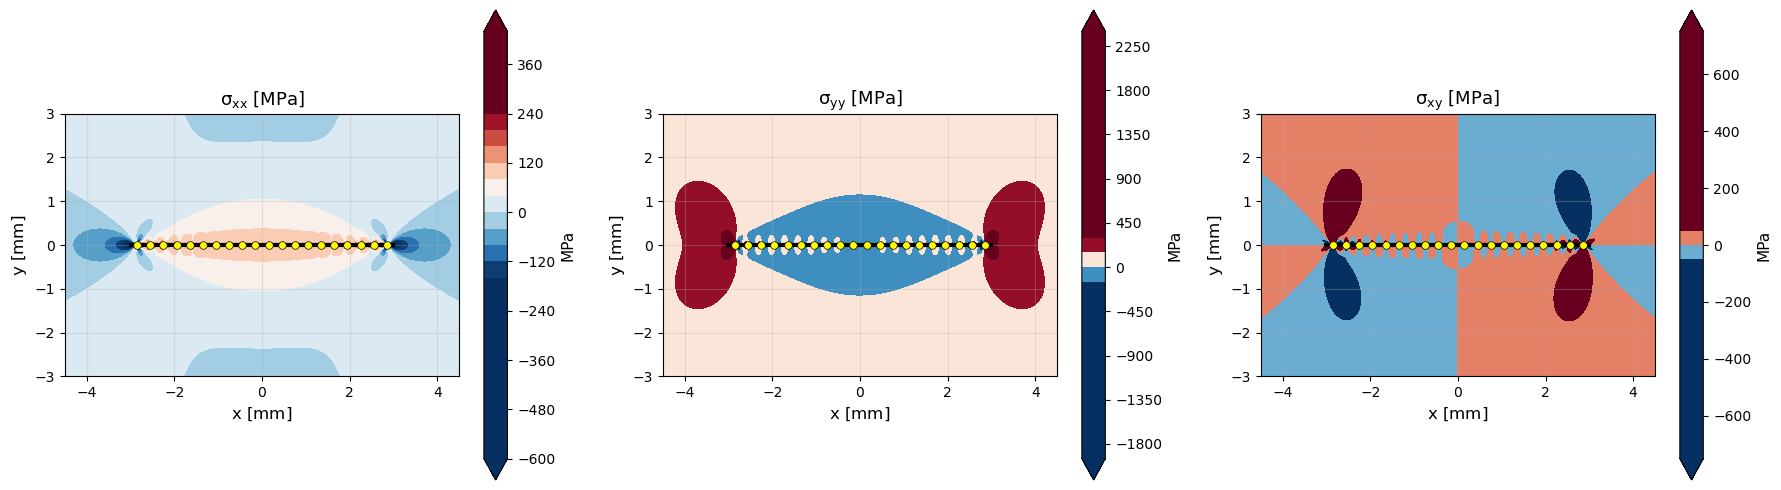

In [1]:
# STRESS FIELD VISUALIZATION - σ_xx, σ_yy, σ_xy contour plots
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.linalg import solve

output_dir = Path('C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output')

class DCEStressFields:
    """DCE with stress field visualization"""
    
    def __init__(self):
        self.mu = 80e9
        self.nu = 0.3
        
    def stress_from_dislocation(self, r, b_vec, disl_pos):
        """Stress from edge dislocation"""
        x = r[0] - disl_pos[0]
        y = r[1] - disl_pos[1]
        r2 = x**2 + y**2
        
        if r2 < (1e-10)**2:
            return np.zeros((2, 2))
        
        D = self.mu / (2 * np.pi * (1 - self.nu))
        r4 = r2 * r2
        bx, by = b_vec[0], b_vec[1]
        
        sig = np.zeros((2, 2))
        
        if abs(bx) > 1e-20:
            sig[0, 0] += -D * bx * y * (3*x**2 + y**2) / r4
            sig[1, 1] += D * bx * y * (x**2 - y**2) / r4
            sig[0, 1] += D * bx * x * (x**2 - y**2) / r4
        
        if abs(by) > 1e-20:
            sig[0, 0] += D * by * x * (x**2 - y**2) / r4
            sig[1, 1] += -D * by * x * (x**2 + 3*y**2) / r4
            sig[0, 1] += -D * by * y * (x**2 - y**2) / r4
        
        sig[1, 0] = sig[0, 1]
        return sig
    
    def stress_from_dipole(self, r, b_magnitude, dipole_x):
        """Stress from dipole"""
        sigma = np.zeros((2, 2))
        sigma += self.stress_from_dislocation(
            r, np.array([0.0, b_magnitude]), np.array([-dipole_x, 0.0])
        )
        sigma += self.stress_from_dislocation(
            r, np.array([0.0, -b_magnitude]), np.array([dipole_x, 0.0])
        )
        return sigma
    
    def solve_burgers_vectors(self, dipole_positions, sigma_applied):
        """Solve for Burgers vectors"""
        n = len(dipole_positions)
        
        A = np.zeros((n-1, n))
        rhs = np.zeros(n-1)
        
        for i in range(1, n):
            x_i = dipole_positions[i]
            eval_pos = np.array([x_i, 0.0])
            rhs[i-1] = -sigma_applied
            
            for j in range(n):
                if i == j:
                    continue
                x_j = dipole_positions[j]
                sigma_ij = self.stress_from_dipole(eval_pos, 1.0, x_j)
                A[i-1, j] = sigma_ij[1, 1]
        
        A_full = np.zeros((n, n))
        A_full[:n-1, :] = A
        rhs_full = np.zeros(n)
        rhs_full[:n-1] = rhs
        
        eval_center = np.array([0.0, 0.0])
        rhs_full[n-1] = -sigma_applied
        
        for j in range(n):
            x_j = dipole_positions[j]
            sigma_j = self.stress_from_dipole(eval_center, 1.0, x_j)
            A_full[n-1, j] = sigma_j[1, 1]
        
        b_magnitudes = solve(A_full, rhs_full)
        return b_magnitudes
    
    def calculate_stress_field(self, dipole_positions, b_magnitudes, sigma_applied, 
                               crack_half_length, grid_size=200):
        """
        Calculate stress field on a grid around the crack
        
        Returns: X, Y, sigma_xx, sigma_yy, sigma_xy
        """
        a = crack_half_length
        
        # Create grid
        x_range = np.linspace(-1.5*a, 1.5*a, grid_size)
        y_range = np.linspace(-1.0*a, 1.0*a, grid_size)
        X, Y = np.meshgrid(x_range, y_range)
        
        # Initialize stress components
        sigma_xx = np.zeros_like(X)
        sigma_yy = np.zeros_like(X)
        sigma_xy = np.zeros_like(X)
        
        print(f"Calculating stress field on {grid_size}x{grid_size} grid...")
        
        # Applied stress
        sigma_app = np.array([[0.0, 0.0], [0.0, sigma_applied]])
        
        # Calculate stress at each grid point
        for i in range(grid_size):
            if i % 20 == 0:
                print(f"  Progress: {i}/{grid_size}")
            
            for j in range(grid_size):
                x = X[i, j]
                y = Y[i, j]
                
                # Skip points on the crack face
                if abs(y) < 1e-10 and abs(x) < a:
                    sigma_xx[i, j] = np.nan
                    sigma_yy[i, j] = np.nan
                    sigma_xy[i, j] = np.nan
                    continue
                
                pos = np.array([x, y])
                
                # Start with applied stress
                sigma_total = sigma_app.copy()
                
                # Add stress from all dipoles
                for k in range(len(dipole_positions)):
                    x_k = dipole_positions[k]
                    b_k = b_magnitudes[k]
                    
                    sigma_total += self.stress_from_dipole(pos, b_k, x_k)
                
                sigma_xx[i, j] = sigma_total[0, 0]
                sigma_yy[i, j] = sigma_total[1, 1]
                sigma_xy[i, j] = sigma_total[0, 1]
        
        print("  Done!")
        
        return X, Y, sigma_xx, sigma_yy, sigma_xy
    
    def solve_crack(self, crack_length, sigma_applied, n_dipoles=20, tip_fraction=0.95):
        """Complete DCE solution"""
        a = crack_length / 2
        
        x_tip = a * tip_fraction
        x_center = a * 0.05
        dipole_positions = np.linspace(x_tip, x_center, n_dipoles)
        
        b_magnitudes = self.solve_burgers_vectors(dipole_positions, sigma_applied)
        
        return dipole_positions, b_magnitudes


# =============================================================================
# GENERATE STRESS FIELD PLOTS
# =============================================================================

print("="*70)
print("STRESS FIELD VISUALIZATION")
print("="*70)

dce = DCEStressFields()
sigma_applied = 100e6
crack_length = 6e-3
a = crack_length / 2
n_dipoles = 10

print(f"\nCrack length: 2a = {crack_length*1e3:.1f} mm")
print(f"Applied stress: σ_∞ = {sigma_applied/1e6:.0f} MPa")
print(f"Number of dipoles: {n_dipoles}")

# Solve for Burgers vectors
dipole_pos, b_mag = dce.solve_crack(crack_length, sigma_applied, n_dipoles)

# Calculate stress field
X, Y, sigma_xx, sigma_yy, sigma_xy = dce.calculate_stress_field(
    dipole_pos, b_mag, sigma_applied, a, grid_size=200
)

# Convert to mm and MPa
X_mm = X * 1e3
Y_mm = Y * 1e3
sigma_xx_MPa = sigma_xx / 1e6
sigma_yy_MPa = sigma_yy / 1e6
sigma_xy_MPa = sigma_xy / 1e6

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colormap limits (symmetric around applied stress)
vmin = -1.5 * sigma_applied / 1e6
vmax = 2.5 * sigma_applied / 1e6

# σ_xx
ax = axes[0]
contour = ax.contourf(X_mm, Y_mm, sigma_xx_MPa, levels=30, cmap='RdBu_r', 
                      vmin=vmin, vmax=vmax, extend='both')
ax.plot([-a*1e3, a*1e3], [0, 0], 'k-', linewidth=3, label='Crack')
ax.scatter(dipole_pos*1e3, [0]*len(dipole_pos), c='yellow', s=30, 
           edgecolors='black', linewidths=0.5, zorder=10)
ax.scatter(-dipole_pos*1e3, [0]*len(dipole_pos), c='yellow', s=30, 
           edgecolors='black', linewidths=0.5, zorder=10)
ax.set_xlabel('$x$ [mm]', fontsize=12, weight='bold')
ax.set_ylabel('$y$ [mm]', fontsize=12, weight='bold')
ax.set_title('$\\sigma_{xx}$ [MPa]', fontsize=13, weight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('MPa', fontsize=11)

# σ_yy
ax = axes[1]
contour = ax.contourf(X_mm, Y_mm, sigma_yy_MPa, levels=30, cmap='RdBu_r', 
                      vmin=vmin, vmax=vmax, extend='both')
ax.plot([-a*1e3, a*1e3], [0, 0], 'k-', linewidth=3, label='Crack')
ax.scatter(dipole_pos*1e3, [0]*len(dipole_pos), c='yellow', s=30, 
           edgecolors='black', linewidths=0.5, zorder=10)
ax.scatter(-dipole_pos*1e3, [0]*len(dipole_pos), c='yellow', s=30, 
           edgecolors='black', linewidths=0.5, zorder=10)
ax.set_xlabel('$x$ [mm]', fontsize=12, weight='bold')
ax.set_ylabel('$y$ [mm]', fontsize=12, weight='bold')
ax.set_title('$\\sigma_{yy}$ [MPa]', fontsize=13, weight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('MPa', fontsize=11)

# σ_xy
ax = axes[2]
vmin_shear = -0.5 * sigma_applied / 1e6
vmax_shear = 0.5 * sigma_applied / 1e6
contour = ax.contourf(X_mm, Y_mm, sigma_xy_MPa, levels=30, cmap='RdBu_r', 
                      vmin=vmin_shear, vmax=vmax_shear, extend='both')
ax.plot([-a*1e3, a*1e3], [0, 0], 'k-', linewidth=3, label='Crack')
ax.scatter(dipole_pos*1e3, [0]*len(dipole_pos), c='yellow', s=30, 
           edgecolors='black', linewidths=0.5, zorder=10)
ax.scatter(-dipole_pos*1e3, [0]*len(dipole_pos), c='yellow', s=30, 
           edgecolors='black', linewidths=0.5, zorder=10)
ax.set_xlabel('$x$ [mm]', fontsize=12, weight='bold')
ax.set_ylabel('$y$ [mm]', fontsize=12, weight='bold')
ax.set_title('$\\sigma_{xy}$ [MPa]', fontsize=13, weight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('MPa', fontsize=11)

plt.tight_layout()
fig.savefig(output_dir / 'stress_fields.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Stress field plots saved to {output_dir / 'stress_fields.png'}")
plt.show()

print("\n" + "="*70)